Loading hardware bitstream...


Hardware loaded!
Configuring IP...
Initial IP Status: 0x4
Starting receive DMA...
Starting IP core...
Starting send DMA...
Success! Hardware finished in 2.96 ms
Final IP Status: 0xe


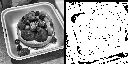

In [1]:
from pynq import Overlay, allocate
import numpy as np
from PIL import Image
import time

# =========================
# 1. Load bitstream
# =========================
print("Loading hardware bitstream...")

overlay = Overlay("sobel_last.bit")
dma = overlay.axi_dma_0
sobel = overlay.sobel_accel_0

print("Hardware loaded!")

# =========================
# 2. Prepare image
# =========================
WIDTH = 64
HEIGHT = 64
THRESHOLD = 50

raw_img = Image.open("test_input.png")
img_gray = raw_img.convert("L").resize((WIDTH, HEIGHT))
image_data = np.array(img_gray, dtype=np.uint8)

# =========================
# 3. Allocate DMA buffers
# =========================
in_buffer = allocate(shape=(HEIGHT, WIDTH), dtype=np.uint8)
out_buffer = allocate(shape=(HEIGHT, WIDTH), dtype=np.uint8)

in_buffer[:] = image_data
out_buffer[:] = 0

in_buffer.flush()

# =========================
# 4. Configure Sobel IP
# =========================
print("Configuring IP...")

sobel.write(0x10, WIDTH)
sobel.write(0x18, HEIGHT)
sobel.write(0x20, THRESHOLD)

print(f"Initial IP Status: {hex(sobel.read(0x00))}")

# =========================
# 5. Start transfer
# Order: recv DMA -> start IP -> send DMA
# =========================
print("Starting receive DMA...")
dma.recvchannel.transfer(out_buffer)

print("Starting IP core...")
sobel.write(0x00, 0x01)

print("Starting send DMA...")
dma.sendchannel.transfer(in_buffer)

# =========================
# 6. Wait with timeout
# =========================
start_t = time.time()
timeout = 5.0

success = False

while True:
    ip_status = sobel.read(0x00)

    send_idle = dma.sendchannel.idle
    recv_idle = dma.recvchannel.idle

    if send_idle and recv_idle:
        process_time = (time.time() - start_t) * 1000
        print(f"Success! Hardware finished in {process_time:.2f} ms")
        print(f"Final IP Status: {hex(ip_status)}")
        success = True
        break

    if time.time() - start_t > timeout:
        print("Timeout! Hardware did not finish.")
        print(f"IP Status: {hex(sobel.read(0x00))}")

        # AXI DMA status registers
        # MM2S_DMASR = 0x04, S2MM_DMASR = 0x34
        print(f"DMA MM2S_DMASR: {hex(dma.read(0x04))}")
        print(f"DMA S2MM_DMASR: {hex(dma.read(0x34))}")
        break

    time.sleep(0.01)

# =========================
# 7. Read result
# =========================
out_buffer.invalidate()

result_img = Image.fromarray(np.array(out_buffer, dtype=np.uint8))

combined = Image.new("L", (WIDTH * 2, HEIGHT))
combined.paste(img_gray, (0, 0))
combined.paste(result_img, (WIDTH, 0))

display(combined)